# 1. Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

print(tf.__version__)

2.19.0


# 2. Dataset Path


In [2]:
DATA_PATH = r"D:\master\02- Second Semester\04- AI\Project\EuroSAT_MS\Processed_Data\NDVI"

# 3. Load Dataset

In [3]:
X = []
y = []

classes = sorted(os.listdir(DATA_PATH))

for class_name in classes:

    class_path = os.path.join(
        DATA_PATH,
        class_name
    )

    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):

        if not file.endswith(".npy"):
            continue

        image = np.load(
            os.path.join(
                class_path,
                file
            )
        )

        # NDVI shape:
        # (64,64) --> (64,64,1)

        image = np.expand_dims(
            image,
            axis=-1
        )

        X.append(image)

        y.append(class_name)

X = np.array(X)

y = np.array(y)

print(X.shape)
print(y.shape)

(27000, 64, 64, 1)
(27000,)


# 4. Encode Labels

In [4]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

num_classes = len(
    encoder.classes_
)

print(encoder.classes_)

['AnnualCrop' 'Forest' 'HerbaceousVegetation' 'Highway' 'Industrial'
 'Pasture' 'PermanentCrop' 'Residential' 'River' 'SeaLake']


# 5. Split data into (Train / Validation / Test)

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(18900, 64, 64, 1)
(4050, 64, 64, 1)
(4050, 64, 64, 1)


# 6. CNN Model

In [6]:
model = Sequential([
    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(64,64,1)
    ),

    BatchNormalization(),
    MaxPooling2D((2,2)),
    Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    BatchNormalization(),
    MaxPooling2D((2,2)),
    Conv2D(
        128,
        (3,3),
        activation="relu"
    ),

    BatchNormalization(),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(
        128,
        activation="relu"
    ),
    Dropout(0.5),
    Dense(
        num_classes,
        activation="softmax"
    )
])

model.summary()

c:\Users\Asmaa\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,810 (2.61 MB)

 Trainable params: 684,362 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

# 7. Compile


In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 8. Callbacks

In [8]:
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_ndvi_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

# 9. Train


In [9]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_val,
        y_val
    ),
    epochs=100,
    batch_size=32,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5672 - loss: 1.5579
Epoch 1: val_accuracy improved from -inf to 0.61407, saving model to best_ndvi_model.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.5673 - loss: 1.5573 - val_accuracy: 0.6141 - val_loss: 1.0626 - learning_rate: 0.0010
Epoch 2/100
590/591 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7159 - loss: 0.8594
Epoch 2: val_accuracy improved from 0.61407 to 0.69012, saving model to best_ndvi_model.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 48s 81ms/step - accuracy: 0.7159 - loss: 0.8593 - val_accuracy: 0.6901 - val_loss: 0.8903 - learning_rate: 0.0010
Epoch 3/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7468 - loss: 0.7386
Epoch 3: val_accuracy did not improve from 0.69012
591/591 ━━━━━━━━━━━━━━━━━━━━ 48s 81ms/step - accuracy: 0.7468 - loss: 0.7386 - val_accuracy: 0.4119 - val_loss: 4.4848 - learning_rate: 0.0010
Epoch 4/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.775

In [10]:
test_loss, test_acc = model.evaluate(
    X_test,
    y_test
)

print(
    f"Test Accuracy = {test_acc:.4f}"
)

127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9155 - loss: 0.2855
Test Accuracy = 0.9079


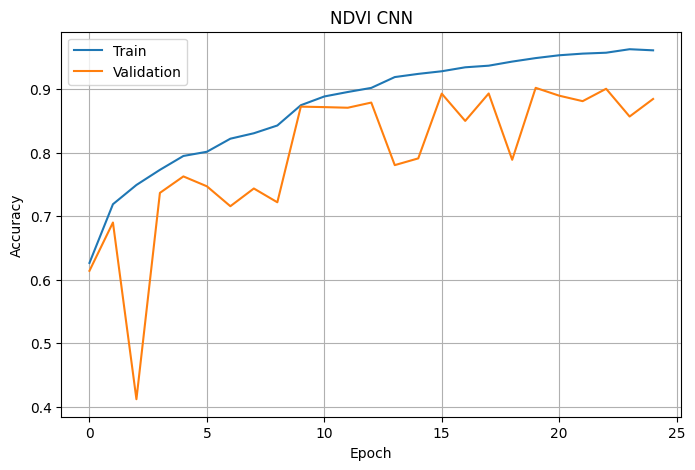

In [12]:
plt.figure(figsize=(8,5))
plt.plot(
    history.history["accuracy"],
    label="Train"
)
plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("NDVI CNN")
plt.legend()
plt.grid()
plt.show()

127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


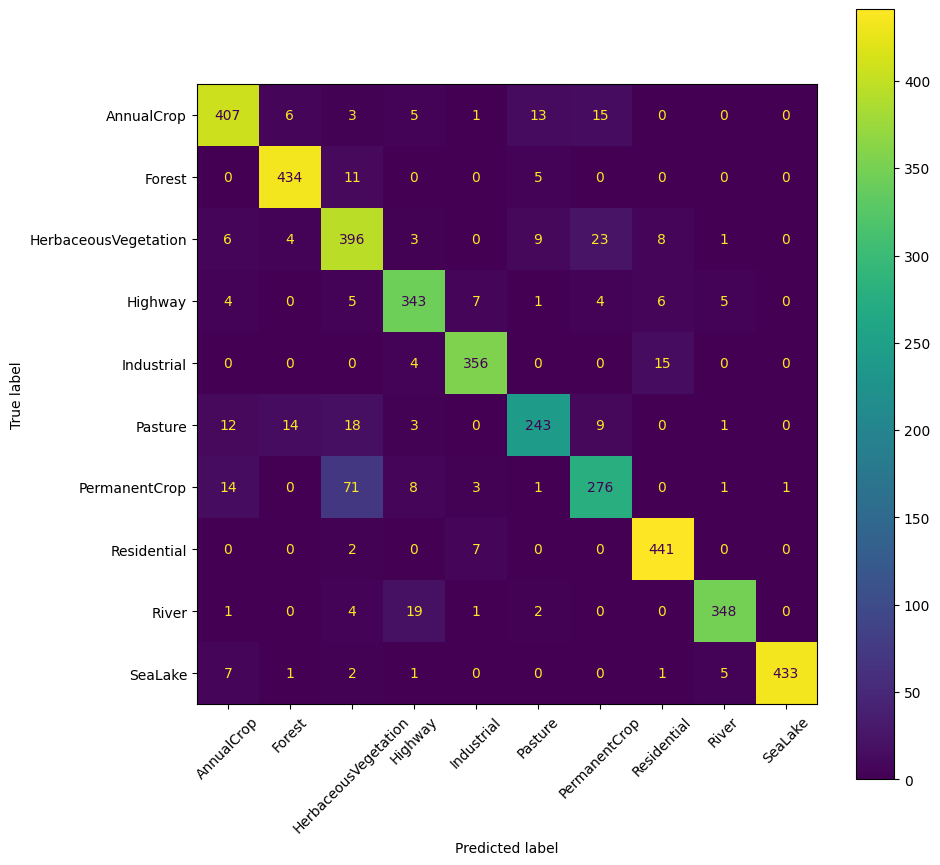

In [13]:
y_pred = model.predict(X_test)
y_pred = np.argmax(
    y_pred,
    axis=1
)

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

fig, ax = plt.subplots(
    figsize=(10,10)
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.show()

In [14]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

                      precision    recall  f1-score   support

          AnnualCrop       0.90      0.90      0.90       450
              Forest       0.95      0.96      0.95       450
HerbaceousVegetation       0.77      0.88      0.82       450
             Highway       0.89      0.91      0.90       375
          Industrial       0.95      0.95      0.95       375
             Pasture       0.89      0.81      0.85       300
       PermanentCrop       0.84      0.74      0.79       375
         Residential       0.94      0.98      0.96       450
               River       0.96      0.93      0.95       375
             SeaLake       1.00      0.96      0.98       450

            accuracy                           0.91      4050
           macro avg       0.91      0.90      0.90      4050
        weighted avg       0.91      0.91      0.91      4050

